In this analysis, a Protest Lifecycle Model was developed to quantify the intensity of protests using three main factors: protest duration, protester violence, and state repression.

By combining these variables into a composite lifecycle score, protests were categorized into four stages ranging from low intensity demonstrations to high intensity unrest.

Import & Theme

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Theme ---
sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=0.9
)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


Load & Inspect Data

In [7]:
df = pd.read_csv("Protest_pg_ready.csv", sep=";", low_memory=False)

df.shape


(14973, 30)

Clean & Fix Formats

In [8]:
# Numeric fixes
num_cols = [
    "Year", "Start Day", "Start Month", "Start Year",
    "End Day", "End Month", "End Year",
    "Protester Violence"
]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["Protester Violence"] = df["Protester Violence"].fillna(0).clip(0,1)

df["Country name"] = df["Country name"].astype(str).str.strip()


Date & Duration

In [9]:
df["start_date"] = pd.to_datetime(
    dict(year=df["Start Year"], month=df["Start Month"], day=df["Start Day"]),
    errors="coerce"
)

df["end_date"] = pd.to_datetime(
    dict(year=df["End Year"], month=df["End Month"], day=df["End Day"]),
    errors="coerce"
)

df["duration_days"] = (
    df["end_date"] - df["start_date"]
).dt.days.clip(lower=0)

df["duration_days"] = df["duration_days"].fillna(0)


Repression Index

In [10]:
response_cols = [c for c in df.columns if "Response" in c]

keywords = [
    "police","arrest","force","violence",
    "repression","crackdown","security","military"
]

df["repression_score"] = df[response_cols].apply(
    lambda row: sum(
        any(k in str(v).lower() for k in keywords)
        for v in row if pd.notna(v)
    ),
    axis=1
)

df["repression_score"] = df["repression_score"].clip(0,3)


In [11]:
df["repression_score"].value_counts().sort_index()


repression_score
0    13110
1     1860
2        3
Name: count, dtype: int64

 Normalize Duration

In [12]:
def normalize(s):
    if s.max() == s.min():
        return pd.Series(0, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

df["duration_norm"] = normalize(df["duration_days"])


Lifecycle Score

In [13]:
df["lifecycle_score"] = (
    0.35 * df["duration_norm"] +
    0.35 * df["Protester Violence"] +
    0.30 * (df["repression_score"] / 3)
)

df["lifecycle_score"] = df["lifecycle_score"].round(3)


Lifecycle Stages

In [16]:
conditions = [
    df["lifecycle_score"] < 0.25,
    (df["lifecycle_score"] >= 0.25) & (df["lifecycle_score"] < 0.5),
    (df["lifecycle_score"] >= 0.5) & (df["lifecycle_score"] < 0.75),
    df["lifecycle_score"] >= 0.75
]

labels = [
    "Low Intensity",
    "Moderate Protest",
    "Escalating Conflict",
    "High Intensity Unrest"
]

df["lifecycle_stage"] = np.select(
    conditions,
    labels,
    default="Unknown"
)



In [17]:
df["lifecycle_stage"].value_counts()


lifecycle_stage
Low Intensity          11405
Moderate Protest        3559
Escalating Conflict        9
Name: count, dtype: int64

 Distribution of Lifecycle Score


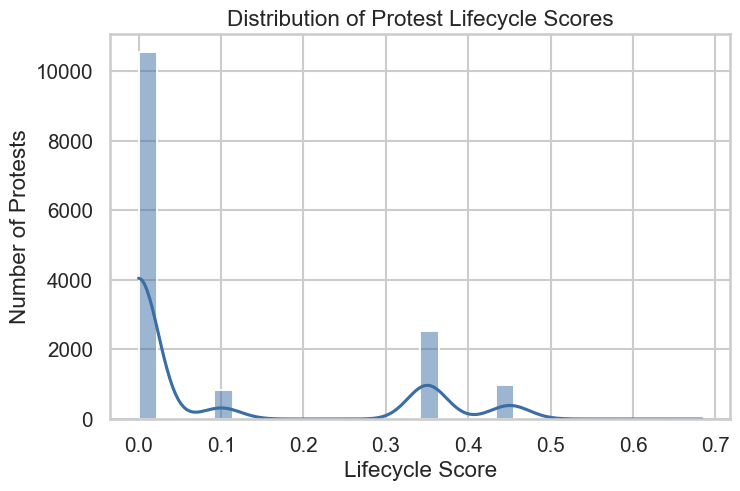

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["lifecycle_score"],
    bins=30,
    kde=True,
    color="#3b6ea5"
)

plt.title("Distribution of Protest Lifecycle Scores")
plt.xlabel("Lifecycle Score")
plt.ylabel("Number of Protests")
plt.show()


Country Risk Profile

In [19]:
country_profile = (
    df.groupby("Country name")
      .agg(
          protests=("Protest ID #","count"),
          avg_duration=("duration_days","mean"),
          violence_rate=("Protester Violence","mean"),
          repression_rate=("repression_score","mean"),
          lifecycle_score=("lifecycle_score","mean")
      )
      .sort_values("lifecycle_score", ascending=False)
      .round(2)
)

country_profile.head(10)


,protests,avg_duration,violence_rate,repression_rate,lifecycle_score
Country name,,,,,
Germany West,2,0.00,0.50,1.00,0.28
Guinea,91,0.86,0.60,0.23,0.23
Dominican Republic,53,0.42,0.53,0.30,0.22
Bangladesh,318,0.46,0.51,0.29,0.21
Kosovo,18,2.11,0.56,0.06,0.20
Congo Kinshasa,62,0.13,0.52,0.19,0.20
Gabon,45,0.62,0.51,0.20,0.20
Uganda,65,1.31,0.46,0.34,0.20
India,174,6.26,0.51,0.11,0.19


Top 10 High-Risk Countries

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16900\3214883923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


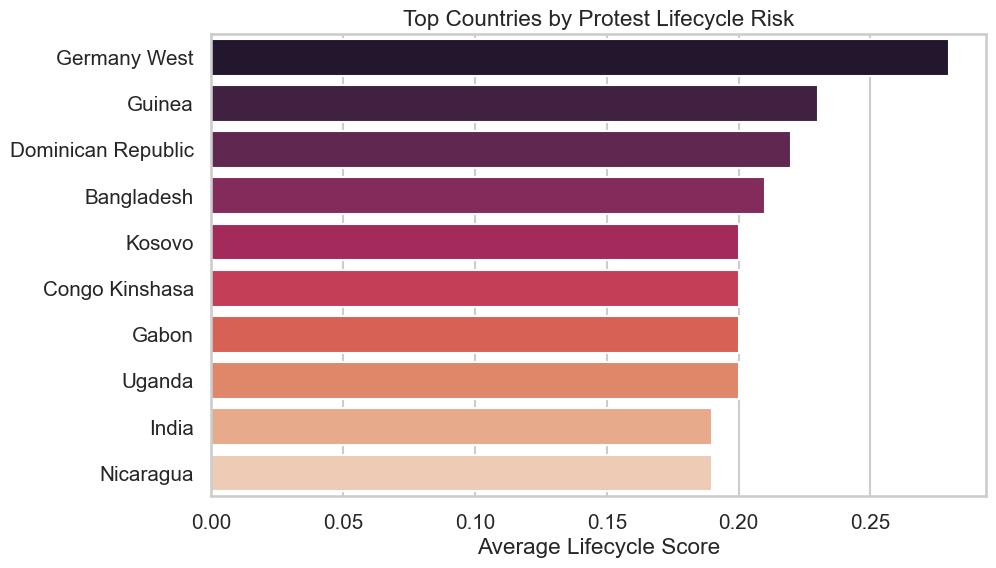

In [20]:
top = country_profile.head(10).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(
    data=top,
    x="lifecycle_score",
    y="Country name",
    palette="rocket"
)

plt.title("Top Countries by Protest Lifecycle Risk")
plt.xlabel("Average Lifecycle Score")
plt.ylabel("")
plt.show()


Global Escalation Trend

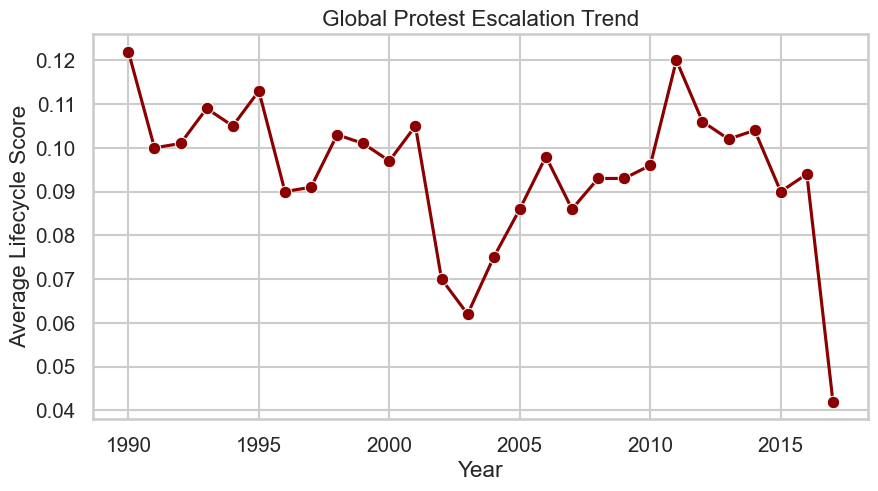

In [21]:
year_trend = (
    df.groupby("Year")
      .agg(
          protests=("Protest ID #","count"),
          lifecycle=("lifecycle_score","mean")
      )
      .reset_index()
      .round(3)
)

plt.figure(figsize=(10,5))
sns.lineplot(
    data=year_trend,
    x="Year",
    y="lifecycle",
    marker="o",
    color="darkred"
)

plt.title("Global Protest Escalation Trend")
plt.ylabel("Average Lifecycle Score")
plt.show()
